# Results

**Sections**
- [Setup](#Setup)
- [Load data](#Load-data)
- [Configuration](#configuration)
- [Fitting and Plotting](#Fitting-and-Plotting)
- [Bootstrap PDP Confidence Intervals](#Bootstrap-PDP-Confidence-Intervals)

We start by loading our training and testing sets, which were created in the notebook `train_test_split`.

In the "Fitting and Plotting" section, we instantiate our pipeline (StandardScaler + RandomForestRegressor) using the parameters that appear most often as the best parameters in our model section step. We fit our model on each health outcome and plot (and save) the results:
- predictions versus the observations,
- residuals versus predictions,
- permutation importance plots,
- PDP (Partial Dependence Plot) for each of the most important feature,
We summarize our results in a dataframe titled **summary** and plot (and save):
- RMSE of our model versus the Dummy baseline across outcomes,
- $R^2$ scores of our model across outcomes.

Finally, in the "Bootstrap PDP Confidence Intervals" section, we manually create confidence intervals for our PDP using a bootstrapping method. Since the program is too long to run, we only apply to the outcome for which we had the best $R^2$ score, i.e., `high_cholesterol_prevalence`, and for the two features with the most importance, i.e., `transit_accessibility_ranked` and `intersection_density_ranked`.

The conclusion of this notebook is similar to what we obtained during our model evaluation phase. Our model does not score significantly higher than the Dummy baseline for any outcomes. Although we did not exhaust all possible models, it appears that the predictive power of walkability features in predicting health outcomes within a census tract is limited. It is possible that our model would achive higher prediction scores if we had access to more features. It is also possible that, even with more features, the census-tract level is too large to predict anything accurately.

 In the future, it would be interesting to explore the following directions:
- Add more walkability features to our covariates, such as proximity to food, healthcare, and nature. It would also be interesting to have access to safety and climate scores at the census-tract level. 
- Explore the same problem using individual-level health data.
- Explore the same problem in a different country.

## Setup

In [1]:
# Setup

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.base import clone
import os

## Load Data

In [2]:
# load the clean datasets
df_train = pd.read_csv("data_train.csv")
df_test = pd.read_csv("data_test.csv")

## Configuration

In [3]:
features = [
    "employment_mix_ranked",
    "employment_residential_mix_ranked",
    "intersection_density_ranked",
    "transit_accessibility_ranked",
]

outcomes = [
    "high_cholesterol_prevalence",
    "depression_prevalence",
    "high_blood_pressure_prevalence",
    "obesity_prevalence",
    "cancer_prevalence",
]

## Fitting and Plotting

We instantiate our Pipeline (imputer + RandomForestRegressor with the parameters appearing most often as best parameters in our model evaluation). Then, we fit our Pipeline on our training set for each of our outcomes. For each outcome:
- we plot the predictions $\hat{y}$ versus the obervation $y$ and save the plots (deviation from the line $y = x$ means poor fit),
- we plot the residuals $y - \hat{y}$ versus the prediction $\hat{y}$ and save the plots (deviation from $x = 0$ means poor fit), 
- we determine the two most important features and save the permutation importance plots,
- we plot the PDP (Partial Dependence Plot) for each of the most important feature and save them,
- we summarize our results in a dataframe title **summary** and plot the RMSE and $R^2$ score for each outcome.

[high_cholesterol_prevalence] Test RMSE=4.368, R^2=0.205 | Dummy Test RMSE=5.024


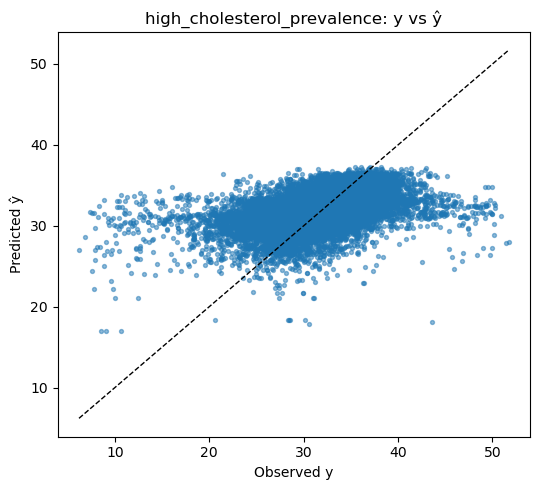

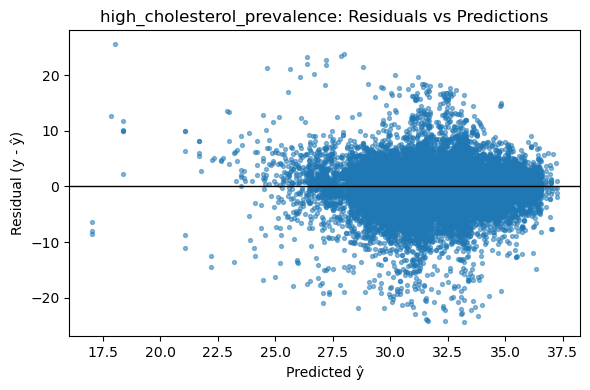

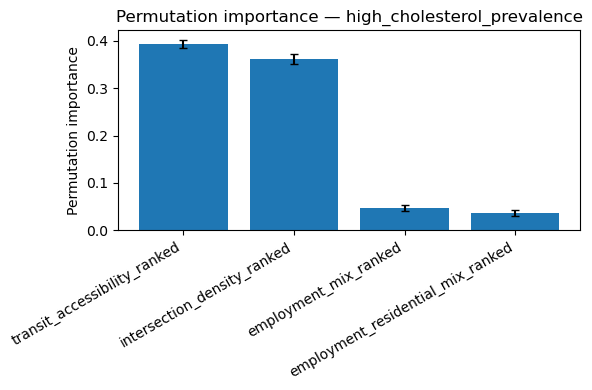

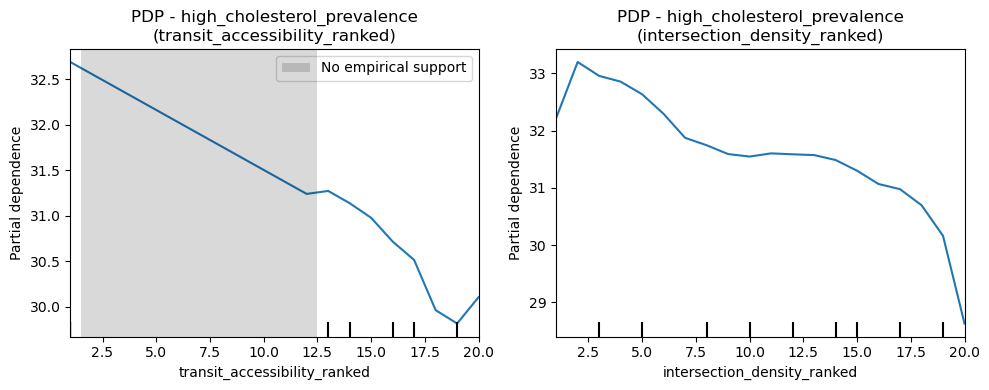

[depression_prevalence] Test RMSE=3.947, R^2=0.049 | Dummy Test RMSE=4.382


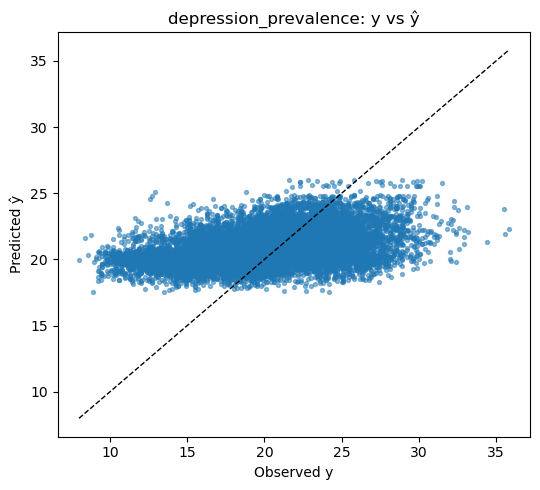

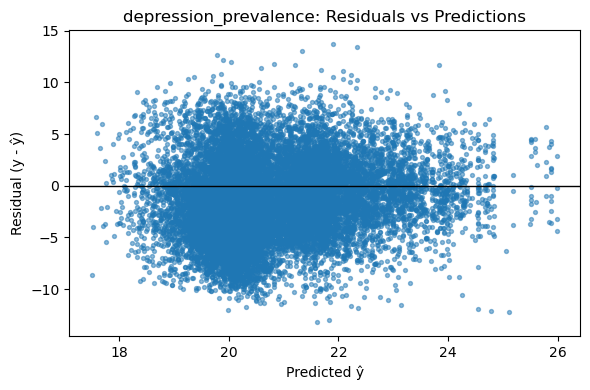

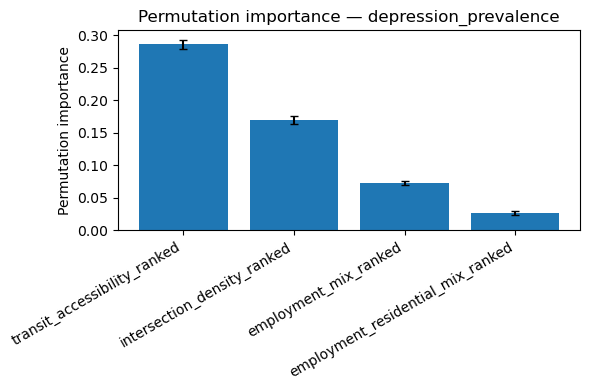

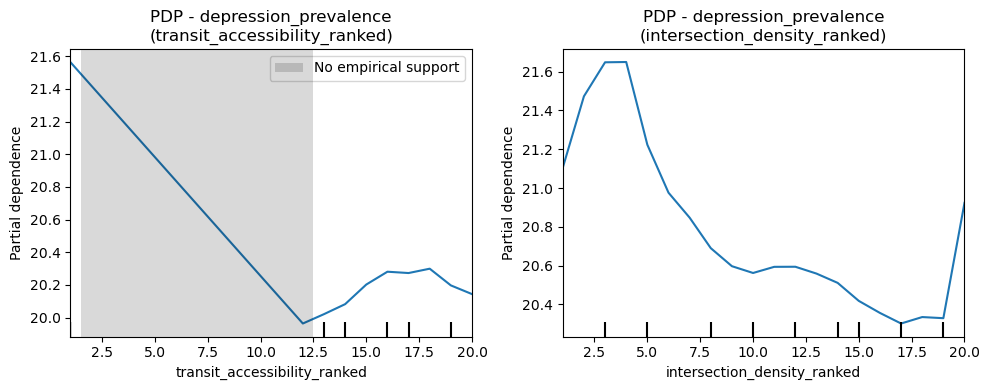

[high_blood_pressure_prevalence] Test RMSE=6.695, R^2=0.129 | Dummy Test RMSE=7.452


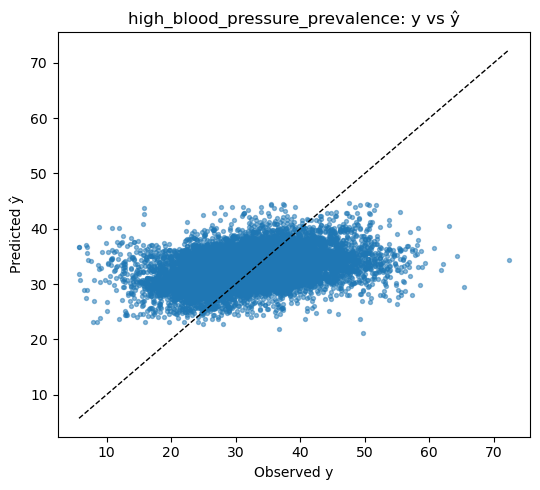

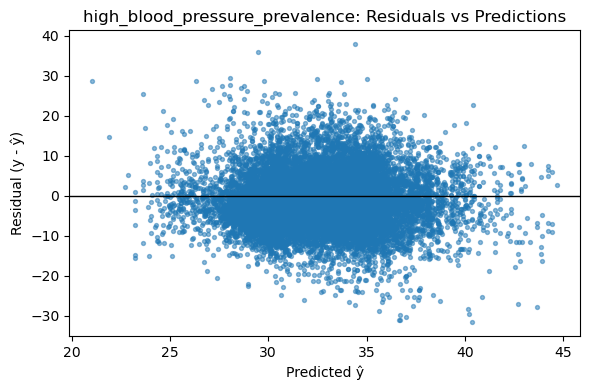

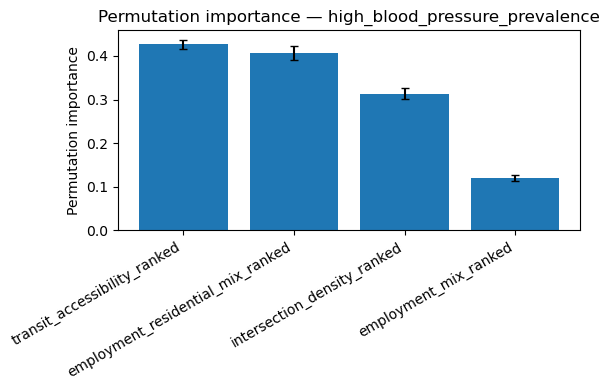

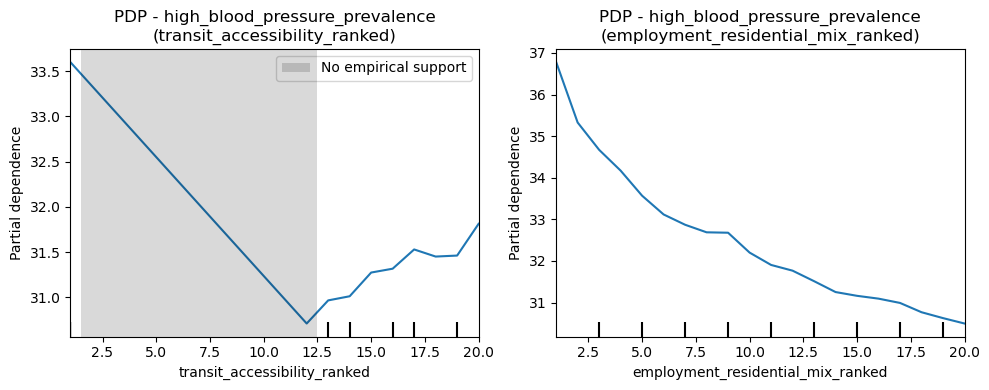

[obesity_prevalence] Test RMSE=6.554, R^2=0.115 | Dummy Test RMSE=7.310


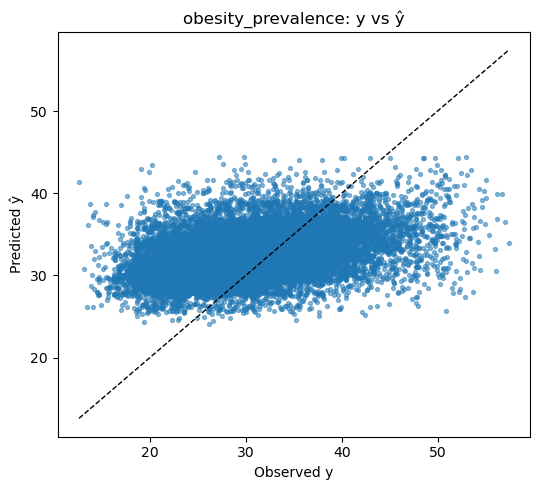

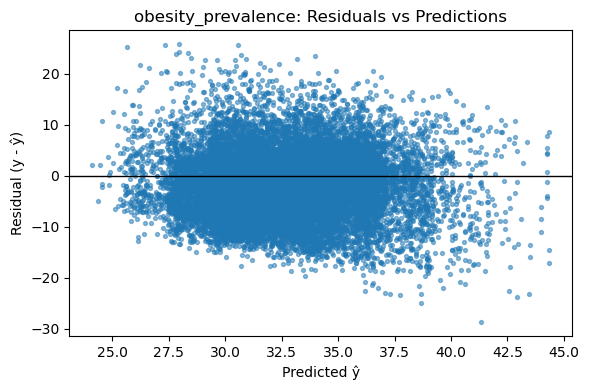

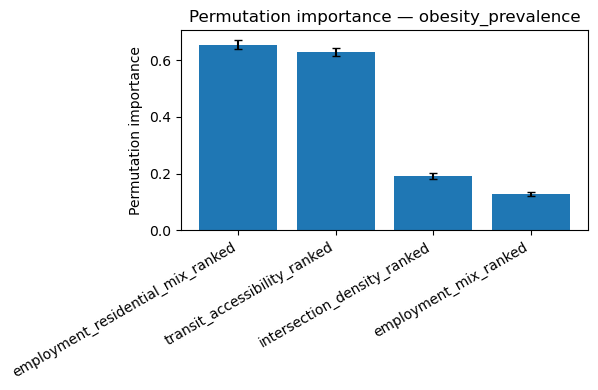

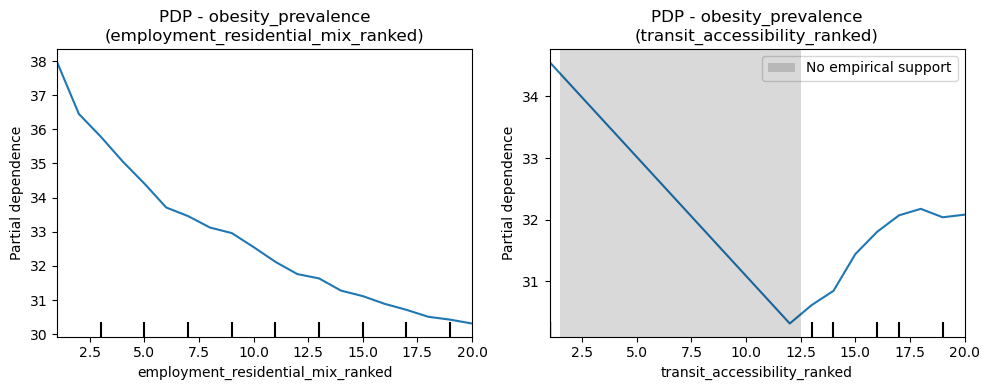

[cancer_prevalence] Test RMSE=1.936, R^2=0.169 | Dummy Test RMSE=2.137


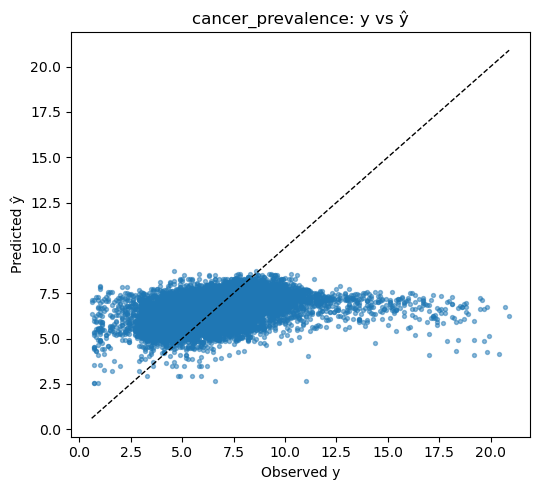

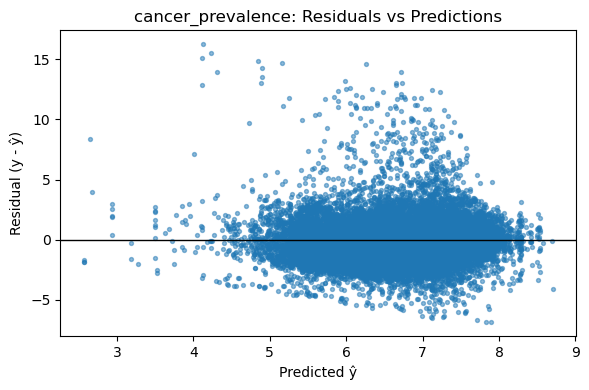

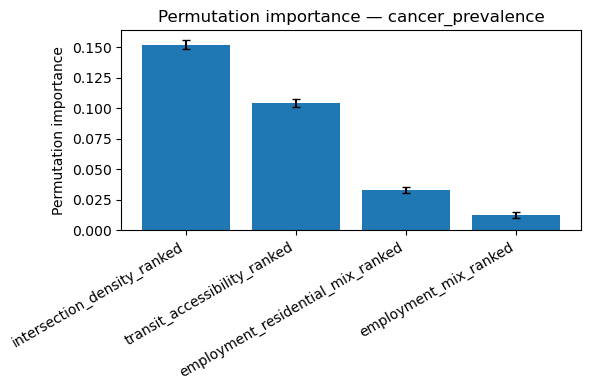

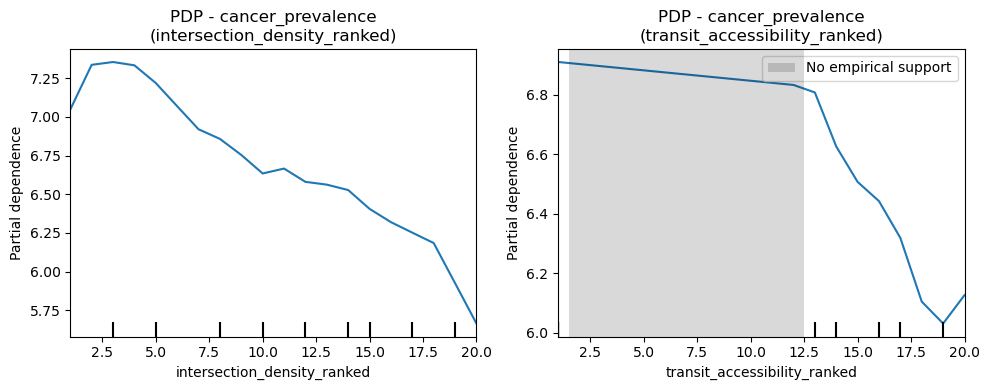

In [ ]:
# We chose the RF best params appearing most often in our model evaluation
best_params = dict(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    min_samples_split=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)

# We instantiate our model
pipe_rf = Pipeline(
    [
        ("imp", SimpleImputer(strategy="median")),
        ("rf", RandomForestRegressor(**best_params)),
    ]
)

# We create the final_artifacts directory within our folder result (if it does not exist yet)
os.makedirs("final_artifacts", exist_ok=True)


# We create a small helper function to get the RMSE from oberved y and predicted hat{y}
def rmse(y, yhat):
    return float(np.sqrt(mean_squared_error(y, yhat)))


# We create an empty summary_rows which we will append in our for loop to add our results
summary_rows = []

# Collect per-outcome importances here
importance_rows = []


# We loop over all possible outcomes
for target in outcomes:

    cols_needed = features + [target]
    tr = df_train.dropna(subset=cols_needed).copy()
    te = df_test.dropna(subset=cols_needed).copy()

    # We convert our training and testing sets to numpy float to avoid the PDP curves warning (they apparently don't want integer values).
    X_train = tr[features].to_numpy(float)
    y_train = tr[target].to_numpy(float)
    X_test = te[features].to_numpy(float)
    y_test = te[target].to_numpy(float)

    # We create a subfolder of final_artifacts for our target (if it does not exist yet)
    out_dir = f"final_artifacts/{target}"
    os.makedirs(out_dir, exist_ok=True)

    # Dummy baseline
    dummy = DummyRegressor(strategy="mean")
    dummy.fit(X_train, y_train)
    yhat_test_dummy = dummy.predict(X_test)
    rmse_test_dummy = rmse(y_test, yhat_test_dummy)

    # RandomForest
    pipe_rf.fit(X_train, y_train)
    yhat_test = pipe_rf.predict(X_test)
    rmse_test = rmse(y_test, yhat_test)
    r2_test = float(r2_score(y_test, yhat_test))

    print(
        f"[{target}] Test RMSE={rmse_test:.3f}, R^2={r2_test:.3f} | Dummy Test RMSE={rmse_test_dummy:.3f}"
    )

    # We plot and save y vs \hat{y}
    plt.figure(figsize=(5.5, 5))
    plt.scatter(y_test, yhat_test, s=8, alpha=0.5)
    lo = min(float(np.min(y_test)), float(np.min(yhat_test)))
    hi = max(float(np.max(y_test)), float(np.max(yhat_test)))
    plt.plot([lo, hi], [lo, hi], "k--", lw=1)  # 45 degree line
    plt.xlabel("Observed y")
    plt.ylabel("Predicted ŷ")
    plt.title(f"{target}: y vs ŷ")
    plt.tight_layout()
    plt.savefig(f"{out_dir}/scatter_test_{target}.png", dpi=150, bbox_inches="tight")
    plt.show()

    # We plot and save residuals vs predictions
    resid_test = y_test - yhat_test
    plt.figure(figsize=(6, 4))
    plt.scatter(yhat_test, resid_test, s=8, alpha=0.5)
    plt.axhline(0, color="k", lw=1)
    plt.xlabel("Predicted ŷ")
    plt.ylabel("Residual (y - ŷ)")
    plt.title(f"{target}: Residuals vs Predictions")
    plt.tight_layout()
    plt.savefig(
        f"{out_dir}/residuals_vs_pred_test_{target}.png", dpi=150, bbox_inches="tight"
    )
    plt.show()

    # Permutation importance on testing set.
    """
    We measure how much the model's error increases when we randomly permute
    one feature at a time. If permuting a feature hurts performance a lot,
    that feature was important to the model's predictions.
    """
    r = permutation_importance(
        pipe_rf,  # fitted model
        X_test,  # evaluate on the test set
        y_test,
        n_repeats=30,  # repeat the permutations 30 times
        random_state=42,  # reproducibility across runs
        n_jobs=-1,  # parallelize across CPUs
        scoring="neg_root_mean_squared_error",  # RMSE_perm - RMSE_base
    )

    # Build a table with mean importance and its std-dev across permutations
    imp = pd.DataFrame(
        {
            "feature": features,
            "perm_importance": r.importances_mean,  # mean RMSE_perm - RMSE_base (positive = worse when shuffled)
            "sd": r.importances_std,  # variability across the n_repeats shuffles
        }
    ).sort_values("perm_importance", ascending=False)

    # We also want to update our importance_rows to get the permutation importance of each feature for each target
    imp2 = imp[["feature", "perm_importance", "sd"]].copy()
    imp2["target"] = target
    importance_rows.append(imp2)

    # Plotting the importances
    plt.figure(figsize=(6, 4))

    order = np.argsort(imp["perm_importance"].values)[
        ::-1
    ]  # we get features from most to least important

    plt.bar(
        np.arange(len(features)),  # x positions for each feature
        imp["perm_importance"].values[order],  # bar heights (mean importance)
        yerr=imp["sd"].values[order],  # error bar size (\pm 1 std across repeats)
        capsize=3,  # little horizontal caps on error bars
    )

    plt.xticks(
        np.arange(len(features)),  # tick positions must match the bar positions
        imp["feature"].values[order],  # the text labels shown under each bar
        rotation=30,
        ha="right",  # rotate and right-align for readability
    )

    plt.ylabel(
        "Permutation importance"
    )  # y-axis label; bigger bar implies bigger RMSE increase when shuffled
    plt.title(f"Permutation importance — {target}")  # figure title with outcome name
    plt.tight_layout()  # prevent label/title clipping
    plt.savefig(
        f"{out_dir}/perm_importance_test.png", dpi=150, bbox_inches="tight"
    )  # save to file
    plt.show()

    # PDPs for the top 2 features (on test) with shaded gap for transit

    top_feats = imp["feature"].head(2).tolist()  # top 2 features
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # two subplots side-by-side

    for ax, f in zip(axes, top_feats):
        # column index of feature f in X_test (Recall X_test = te[features])
        j = features.index(f)

        # Draw the PDP for feature j. We capture the returned display.
        disp = PartialDependenceDisplay.from_estimator(
            pipe_rf,
            X_test,
            [j],  # list with a single feature index
            feature_names=features,
            ax=ax,
            kind="average",  # standard PDP (average over other features)
            centered=False,  # plot raw PDP curve, not centered at mean
        )

        # PartialDependenceDisplay can create/replace axes, so we recover the axis it actually used.
        ax_used = disp.axes_[0, 0]

        # Set the title on the actual axis
        ax_used.set_title(f"PDP - {target}\n({f})")

        # Range in the x-axis
        ax_used.set_xlim(1, 20)

        # Special shading for the transit rank gap (no empirical support in 1.5–12.5)
        if f == "transit_accessibility_ranked":

            # Shade region [1.5, 12.5] = ranks where we have no observed tracts
            ax_used.axvspan(
                1.5,
                12.5,
                facecolor="black",
                alpha=0.15,
                zorder=10,
                label="No empirical support",
            )

            # Add legend once we've added the shaded patch
            ax_used.legend(loc="best")

    plt.tight_layout()
    plt.savefig(f"{out_dir}/pdp_top_features.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Append to summary
    summary_rows.append(
        {
            "target": target,
            "rmse_test": round(rmse_test, 3),
            "r2_test": round(r2_test, 3),
            "rmse_test_dummy": round(rmse_test_dummy, 3),
        }
    )

# Final summary across outcomes
summary = pd.DataFrame(summary_rows).sort_values("rmse_test").reset_index(drop=True)
summary.to_csv("final_artifacts/summary_rf_all_outcomes.csv", index=False)
summary

# Importance scores table: rows are our features  and columns our outcomes (values = mean permutation importance accross all permutations)
imp_all = pd.concat(importance_rows, ignore_index=True)
imp_wide = imp_all.pivot(index="feature", columns="target", values="perm_importance")
imp_wide_rounded = imp_wide.round(2)
imp_wide_rounded.to_csv(
    "final_artifacts/perm_importance_wide.csv"
)  # round to 2 decimals in-memory

We grayed out the zone between 1.5 and 12.5 in the case where the feature with most importance is `transit_accessibility_ranked` since no such values are avalable by construction.

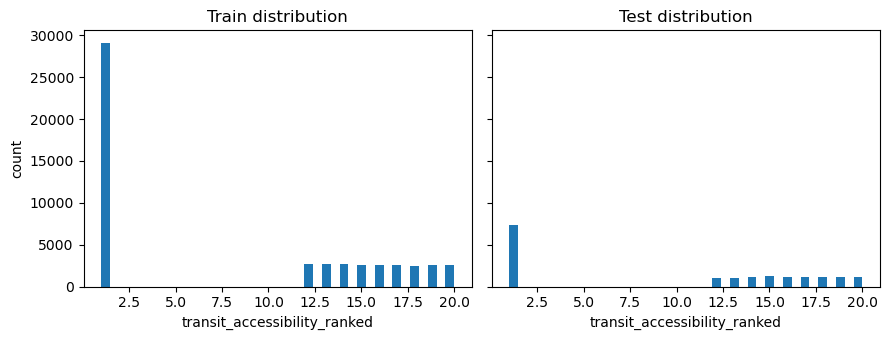

In [5]:
fig, ax = plt.subplots(1,2, figsize=(9,3.5), sharey=True)
ax[0].hist(df_train["transit_accessibility_ranked"].dropna(), bins=40)
ax[0].set_title("Train distribution")
ax[1].hist(df_test["transit_accessibility_ranked"].dropna(), bins=40)
ax[1].set_title("Test distribution")
for a in ax: a.set_xlabel("transit_accessibility_ranked")
ax[0].set_ylabel("count")
plt.tight_layout(); plt.show()

Let's plot the RMSE of our model versus dummy accross outcomes and the $R^2$ scores.

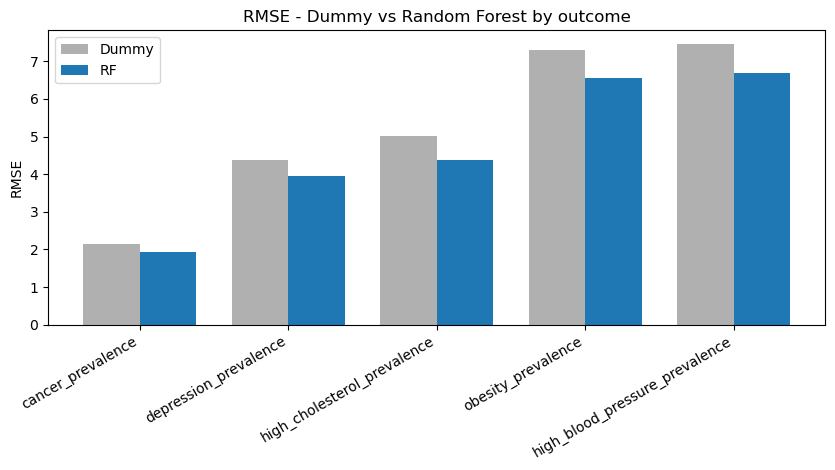

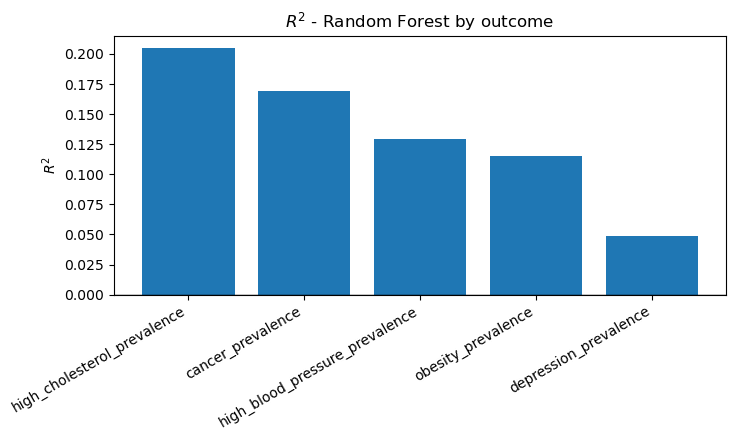

In [6]:
# Save folder
PLOTS_DIR = "final_artifacts/plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- fig1: Dummy vs RF Test RMSE (grouped bars) ---
df_cmp = summary.sort_values("rmse_test", ascending=True)[
    ["target", "rmse_test", "rmse_test_dummy"]
].copy()

x = np.arange(len(df_cmp))
w = 0.38

plt.figure(figsize=(8.5, 4.8))
plt.bar(x - w / 2, df_cmp["rmse_test_dummy"], width=w, label="Dummy", color="#B0B0B0")
plt.bar(x + w / 2, df_cmp["rmse_test"], width=w, label="RF")
plt.xticks(x, df_cmp["target"], rotation=30, ha="right")
plt.ylabel("RMSE")
plt.title("RMSE - Dummy vs Random Forest by outcome")
plt.legend()
plt.tight_layout()
fig1_path = f"{PLOTS_DIR}/rmse_dummy_vs_rf.png"
plt.savefig(fig1_path, dpi=150, bbox_inches="tight")
plt.show()

# --- fig2: Test R^2 by outcome (vertical bars) ---
df_r2 = summary.sort_values("r2_test", ascending=False).copy()

plt.figure(figsize=(7.5, 4.5))
plt.bar(df_r2["target"], df_r2["r2_test"])
plt.axhline(0, color="k", linewidth=1)
plt.xticks(rotation=30, ha="right")
plt.ylabel("$R^2$")
plt.title("$R^2$ - Random Forest by outcome")
plt.tight_layout()
fig2_path = f"{PLOTS_DIR}/rf_test_r2_by_outcome.png"
plt.savefig(fig2_path, dpi=150, bbox_inches="tight")
plt.show()

## Bootstrap PDP Confidence Intervals

We manually create confidence intervals for our PDP via a bootstrapping method. Since the program is long to run, we only apply to the outcome for which we had the best $R^2$ score, i.e., `high_cholesterol_prevalence`, and for the two feature with the most importance, i.e. `transit_accessibility_ranked` and `intersection_density_ranked`.

### Definining the PDP bootstrap

In [7]:
def pd_curve_on_grid(model, X, j, grid):
    """
    Compute a 1D Partial Dependence (PD) curve for feature j on a chosen grid.

    Parameters:
    - model = fitted model.
    - X = array-like, shape (n_samples, n_features), the dataset over which to average the dependence.
    - j = int, column index of the feature to analyze.
    - grid = array-like, shape (G,), values of the j-th feature at which to evaluate the PD curve.

    Returns:
    means = np.ndarray, shape (G,), the average predictions at each grid value (the PD curve).

    Math:
    PD_j(v) = (1/n) * sum_{i=1...n}  hat{f}( v, x_{-j}^{(i)} )
    """
    # Ensure we have a NumPy array view of X (won't modify caller's data)
    X = np.asarray(X)

    # Prepare output: one mean prediction per grid value
    means = np.empty(len(grid), dtype=float)

    # Loop over grid values v
    for t, v in enumerate(grid):
        # Make a copy so we don't overwrite the original X
        Xv = X.copy()

        # Set the j-th feature to v for all rows (holding others fixed)
        # This constructs the counterfactual batch (v, x_{-j}^{(i)})
        Xv[:, j] = v

        # Predict on this counterfactual batch, then average across rows
        means[t] = model.predict(Xv).mean()

    # Return the PD curve sampled on 'grid'
    return means

In [8]:
def pd_bootstrap_band_refit(
    pipe_template,  # unfitted model with our hyperparams
    X_train,
    y_train,
    X_test,
    j,  # integer column index of the feature to analyze
    grid,  # 1D array of values of shape (G,) at which to evaluate the PD curve
    B=150,  # number of bootstrap refits
    alpha=0.05,  # 1 - alpha central band (e.g., 0.05 to get 95% confidence interval)
    frac_train=0.7,  # m-out-of-n fraction for train resampling
    frac_test=0.7,  # m-out-of-n fraction for test resampling (for PD averaging)
    random_state=42,
):
    """
    Returns:
    - grid = (G,) array, (echoed back)
    - mean = (G,) array, pointwise mean PD across bootstrap refits
    - lo = (G,) array, pointwise lower percentile (alpha/2)
    - hi = (G,) array, pointwise upper percentile (1 - alpha/2)

    Math:
    For b = 1...B:
    1) Sample frac_train * n_train rows WITH replacement from (X_train, y_train).
    2) Fit a fresh clone of pipe_template on this bootstrap sample.
    3) Sample frac_test * n_test rows WITH replacement from X_test.
    4) Compute the PD curve on 'grid' by averaging predictions over that sampled X_test.
    5) Aggregate curves to get mean and percentile band.
    """
    rng = np.random.default_rng(random_state)

    X_train = np.asarray(X_train, float)
    y_train = np.asarray(y_train, float)
    X_test = np.asarray(X_test, float)
    grid = np.asarray(grid, float)

    n_tr = len(X_train)
    n_te = len(X_test)

    # Simple row-resampling helper (no groups)
    def _resample_rows(n, frac):
        m = max(2, int(frac * n))
        return rng.integers(0, n, size=m)  # with replacement

    curves = []  # will be (B, G)

    for _ in range(B):
        # 1) Bootstrap TRAIN
        idx_tr = _resample_rows(n_tr, frac_train)
        X_tr_b = X_train[idx_tr]
        y_tr_b = y_train[idx_tr]

        # 2) Fit fresh clone
        est = clone(pipe_template)
        est.fit(X_tr_b, y_tr_b)

        # 3) Bootstrap TEST subset (for PD averaging)
        idx_te = _resample_rows(n_te, frac_test)
        X_te_b = X_test[idx_te]

        # 4) PD curve on this draw
        curves.append(pd_curve_on_grid(est, X_te_b, j, grid))

    curves = np.vstack(curves)  # shape (B, G)
    mean = curves.mean(axis=0)  # mean PD curve over bootstraps
    lo = np.percentile(curves, 100 * alpha / 2, axis=0)  # Pointwise lower percentile
    hi = np.percentile(
        curves, 100 * (1 - alpha / 2), axis=0
    )  # Pointwise upper percentile

    return grid, mean, lo, hi

### high_cholesterol_prevalence vs transit_accessibility_ranked

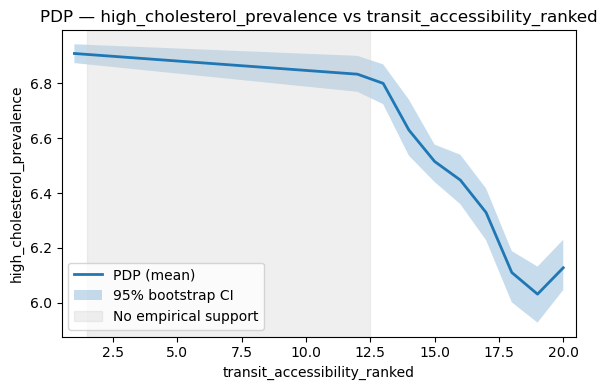

In [9]:
pipe_rf_template = clone(pipe_rf)

# Choose feature
feat = "transit_accessibility_ranked"
target = "high_cholesterol_prevalence"
j = features.index(feat)

# Use observed support for gappy ranks (cleanest)
grid = np.sort(np.unique(X_test[:, j]).astype(float))

# We apply our pd_bootstrap_band_refit function
grid, mean, lo, hi = pd_bootstrap_band_refit(
    pipe_template=pipe_rf_template,  # unfitted template (NOT the already-fitted pipe)
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    j=j,
    grid=grid,
    B=120,  # bump to 200+ if you have time
    alpha=0.05,  # 10–90% band; use 0.05 for 95%
    frac_train=0.7,  # 70% m-out-of-n bootstrap on train
    frac_test=0.7,  # 70% m-out-of-n bootstrap on test
)

plt.figure(figsize=(6, 4))
plt.plot(grid, mean, lw=2, label="PDP (mean)")
plt.fill_between(grid, lo, hi, alpha=0.25, label="95% bootstrap CI")

# Optional: shade unsupported ranks if you ever use a dense grid
if feat == "transit_accessibility_ranked":
    plt.xlim(0.5, 20.5)
    plt.axvspan(1.5, 12.5, color="lightgray", alpha=0.35, label="No empirical support")

plt.xlabel(feat)
plt.ylabel(target)
plt.title(f"PDP — {target} vs {feat}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/pdp_bootstrap_refit_{feat}.png", dpi=150, bbox_inches="tight")
plt.show()

### high_cholesterol_prevalence vs intersection_density_ranked

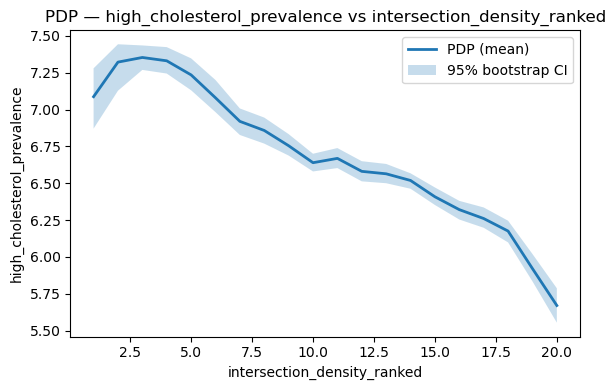

In [10]:
pipe_rf_template = clone(pipe_rf)

# Choose feature
feat = "intersection_density_ranked"
target = "high_cholesterol_prevalence"
j = features.index(feat)

# Use observed support for gappy ranks (cleanest)
grid = np.sort(np.unique(X_test[:, j]).astype(float))

# We apply our pd_bootstrap_band_refit function
grid, mean, lo, hi = pd_bootstrap_band_refit(
    pipe_template=pipe_rf_template,  # unfitted template (NOT the already-fitted pipe)
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    j=j,
    grid=grid,
    B=120,  # bump to 200+ if you have time
    alpha=0.05,  # 10–90% band; use 0.05 for 95%
    frac_train=0.7,  # 70% m-out-of-n bootstrap on train
    frac_test=0.7,  # 70% m-out-of-n bootstrap on test
)

plt.figure(figsize=(6, 4))
plt.plot(grid, mean, lw=2, label="PDP (mean)")
plt.fill_between(grid, lo, hi, alpha=0.25, label="95% bootstrap CI")

# Optional: shade unsupported ranks if you ever use a dense grid
if feat == "transit_accessibility_ranked":
    plt.xlim(0.5, 20.5)
    plt.axvspan(1.5, 12.5, color="lightgray", alpha=0.35, label="No empirical support")

plt.xlabel(feat)
plt.ylabel(target)
plt.title(f"PDP — {target} vs {feat}")
plt.legend()
plt.tight_layout()
plt.savefig(f"{out_dir}/pdp_bootstrap_refit_{feat}.png", dpi=150, bbox_inches="tight")
plt.show()